In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. MEMBACA & MEMBERSIHKAN DATASET KAGGLE
# ==========================================
# Membaca file CSV dari folder proyek kamu
df_raw = pd.read_csv('realtor-data.zip.csv')

# Memilih kolom yang diperlukan dan menghapus baris yang kosong (NaN) agar tidak error
data = df_raw[['house_size', 'price']].dropna()

# Membatasi data (misal: 500 baris pertama) agar proses training cepat dan grafik tidak terlalu padat
data = data.head(500)

print("--- 5 Data Pertama Realtor Dataset ---")
print(data.head())
print("\n" + "="*40 + "\n")

--- 5 Data Pertama Realtor Dataset ---
   house_size     price
0       920.0  105000.0
1      1527.0   80000.0
2       748.0   67000.0
3      1800.0  145000.0
5      2520.0  179000.0




In [11]:
# ==========================================
# 2. PEMBAGIAN DATA (TRAIN & TEST SPLIT)
# ==========================================
# Menentukan X (Luas Rumah) dan y (Harga Rumah)
X = data[['house_size']]
y = data['price']

# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")
print("\n" + "="*40 + "\n")

Jumlah data latih: 400
Jumlah data uji: 100




In [12]:
# ==========================================
# 3. PELATIHAN MODEL (TRAINING)
# ==========================================
# Inisialisasi dan latih model Linear Regression
model_regresi = LinearRegression()
model_regresi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# ==========================================
# 4. PREDIKSI DAN EVALUASI
# ==========================================
# Membuat prediksi menggunakan data uji
y_pred = model_regresi.predict(X_test)

# Menghitung performa model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Model Kaggle ---")
print(f"Koefisien (Kemiringan): {model_regresi.coef_[0]:.2f}")
print(f"Intercept (Konstanta): {model_regresi.intercept_:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.2f} (Model menjelaskan {(r2*100):.1f}% variasi data)")
print("\n" + "="*40 + "\n")

--- Hasil Evaluasi Model Kaggle ---
Koefisien (Kemiringan): 306.73
Intercept (Konstanta): 251303.85
Mean Squared Error (MSE): 2405035703019.25
R-squared Score: 0.18 (Model menjelaskan 17.7% variasi data)




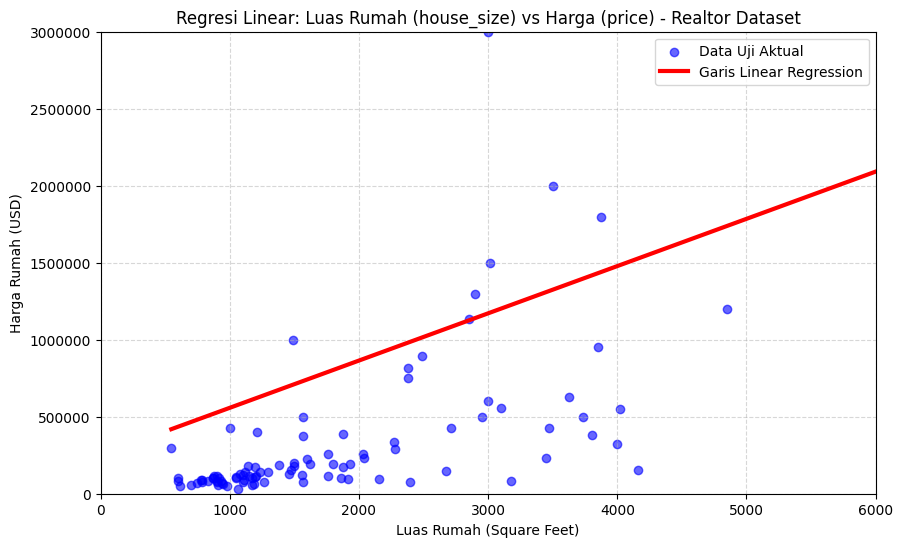

In [15]:
# ==========================================
# 5. VISUALISASI HASIL REGRESI (VERSI RAPI)
# ==========================================
plt.figure(figsize=(10, 6))

# 1. Plot titik data asli hasil pengujian
plt.scatter(X_test, y_test, color='blue', alpha=0.6, label='Data Uji Aktual')

# 2. Mengurutkan X_test agar garis regresi ditarik lurus sempurna tanpa patah-patah
idx_urut = X_test.reset_index(drop=True).sort_values(by='house_size').index
X_test_urut = X_test.iloc[idx_urut]
y_pred_urut = pd.Series(y_pred).iloc[idx_urut]

# 3. Plot garis regresi hasil prediksi
plt.plot(X_test_urut, y_pred_urut, color='red', linewidth=3, label='Garis Linear Regression')

# 4. MEMBATASI SUMBU (Agar fokus pada kerumunan data dan mengabaikan pencilan)
# Kita batasi luas rumah maksimal 6000 sqft dan harga rumah maksimal 3 juta USD
plt.xlim(0, 6000)
plt.ylim(0, 3000000)

# 5. Mengatur format angka pada sumbu Y agar tidak menggunakan notasi ilmiah (1e7)
plt.ticklabel_format(style='plain', axis='y')

plt.title('Regresi Linear: Luas Rumah (house_size) vs Harga (price) - Realtor Dataset')
plt.xlabel('Luas Rumah (Square Feet)')
plt.ylabel('Harga Rumah (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Menampilkan grafik di VS Code
plt.show()